# Heat Risk Sensor Screening

Use mobile sensor observations and district polygons to identify likely urban heat hotspots.

This OpenGeoLab case is self-contained: all inputs live in `data/`, and outputs are written to `outputs/`.

Inspired by urban heat island exploratory notebooks; all sample observations are bundled locally for offline execution.

In [1]:
import os
os.environ.setdefault("PROJ_DATA", "/opt/conda/share/proj")
os.environ.setdefault("PROJ_LIB", "/opt/conda/share/proj")
from pathlib import Path
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns
import folium
from IPython.display import display

DATA = Path('data')
OUT = Path('outputs')
OUT.mkdir(exist_ok=True)
zones = gpd.read_file(DATA / 'zones.geojson')
obs = pd.read_csv(DATA / 'observations.csv')
points = gpd.GeoDataFrame(obs, geometry=gpd.points_from_xy(obs.lon, obs.lat), crs='EPSG:4326')
print({'zones': len(zones), 'observations': len(points), 'crs': str(zones.crs)})
display(zones.head())


{'zones': 25, 'observations': 100, 'crs': 'EPSG:4326'}


,zone_id,district,score,population,green_ratio,geometry
0,Z0000,District 1,51.178339,8344,0.196574,"POLYGON ((118.725 31.9, 118.725 31.922, 118.7 ..."
1,Z0001,District 1,47.823522,6589,0.167927,"POLYGON ((118.76 31.9, 118.76 31.922, 118.735 ..."
2,Z0002,District 1,41.758274,7040,0.150888,"POLYGON ((118.795 31.9, 118.795 31.922, 118.77..."
3,Z0003,District 1,36.663747,6103,0.193979,"POLYGON ((118.83 31.9, 118.83 31.922, 118.805 ..."
4,Z0004,District 1,31.347166,8079,0.134483,"POLYGON ((118.865 31.9, 118.865 31.922, 118.84..."


In [2]:
joined = gpd.sjoin(points, zones[['zone_id', 'score', 'geometry']], predicate='within', how='left')
summary = joined.groupby('zone_id').agg(mean_value=('value', 'mean'), observations=('id', 'count')).reset_index()
zones2 = zones.merge(summary, on='zone_id', how='left').fillna({'mean_value': 0, 'observations': 0})
zones2['priority_index'] = (zones2['mean_value'] * 0.65 + zones2['score'] * 0.35).round(2)
display(zones2[['zone_id', 'score', 'mean_value', 'observations', 'priority_index']].sort_values('priority_index', ascending=False).head(8))


,zone_id,score,mean_value,observations,priority_index
1,Z0001,47.823522,77.250000,2.0,66.95
2,Z0002,41.758274,76.170000,2.0,64.13
6,Z0101,49.725834,71.203333,3.0,63.69
0,Z0000,51.178339,68.790000,2.0,62.63
11,Z0201,59.756838,63.930000,1.0,62.47
12,Z0202,51.363459,68.355000,2.0,62.41
5,Z0100,53.410358,64.976667,3.0,60.93
8,Z0103,41.049203,68.350000,3.0,58.79


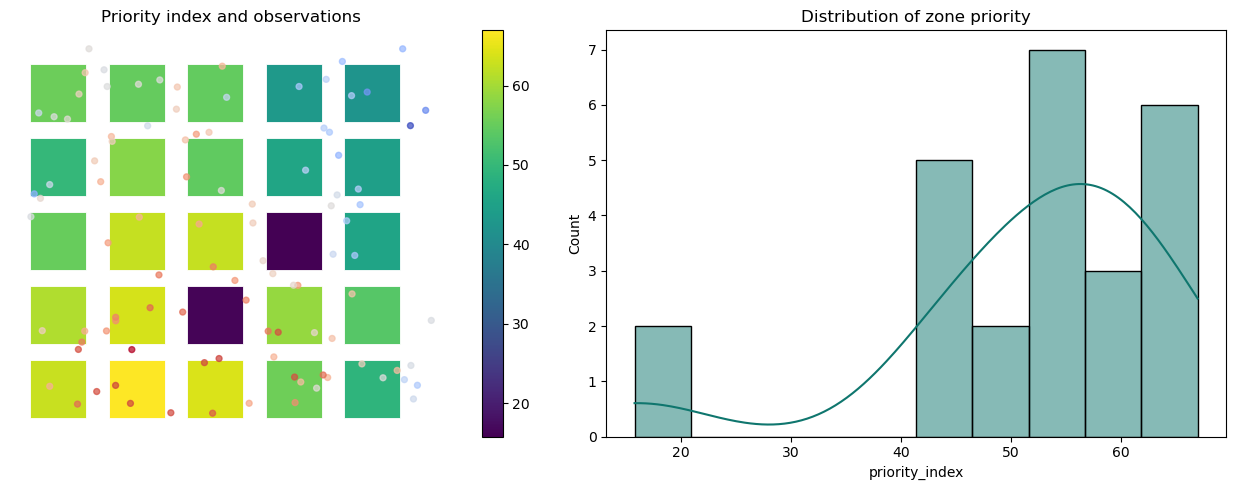

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
zones2.plot(column='priority_index', cmap='viridis', legend=True, ax=axes[0], edgecolor='white', linewidth=0.6)
points.plot(column='value', cmap='coolwarm', markersize=18, alpha=0.72, ax=axes[0])
axes[0].set_title('Priority index and observations')
axes[0].set_axis_off()
sns.histplot(zones2['priority_index'], bins=10, kde=True, ax=axes[1], color='#0f766e')
axes[1].set_title('Distribution of zone priority')
fig.tight_layout()
fig.savefig(OUT / 'priority_map.png', dpi=160)
plt.show()


In [4]:
center = [points.geometry.y.mean(), points.geometry.x.mean()]
m = folium.Map(location=center, zoom_start=12, tiles='CartoDB positron')
folium.Choropleth(
    geo_data=zones2.to_json(), data=zones2, columns=['zone_id', 'priority_index'], key_on='feature.properties.zone_id',
    fill_color='YlOrRd', fill_opacity=0.62, line_opacity=0.3, legend_name='Priority index'
).add_to(m)
for row in points.sample(min(35, len(points)), random_state=7).itertuples():
    folium.CircleMarker([row.lat, row.lon], radius=3, color='#1d4ed8', fill=True, fill_opacity=0.72, popup=f'{row.id}: {row.value}').add_to(m)
m.save(OUT / 'interactive_map.html')
display(m)


In [5]:
top = zones2.sort_values('priority_index', ascending=False).head(5)
print('Top intervention zones:')
for row in top.itertuples():
    print(f'- {row.zone_id}: priority={row.priority_index}, observations={int(row.observations)}')


Top intervention zones:
- Z0001: priority=66.95, observations=2
- Z0002: priority=64.13, observations=2
- Z0101: priority=63.69, observations=3
- Z0000: priority=62.63, observations=2
- Z0201: priority=62.47, observations=1
